In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
pd.set_option('display.max_columns', 20)

In [30]:
x = pd.read_csv('credit card.csv')
x = x.drop('CUST_ID' ,axis=1)
x.ffill(inplace=True)
print(x.head())

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

In [31]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_normailized = normalize(x_scaled)
x_normailized = pd.DataFrame(x_normailized)

pca = PCA(n_components=2)
x_principal = pca.fit_transform(x_normailized)
x_principal = pd.DataFrame(x_principal)
x_principal.columns = ['P1','P2']

print(x_principal.head())

         P1        P2
0 -0.489949 -0.679976
1 -0.519099  0.544827
2  0.330633  0.268879
3 -0.481656 -0.097611
4 -0.563512 -0.482506


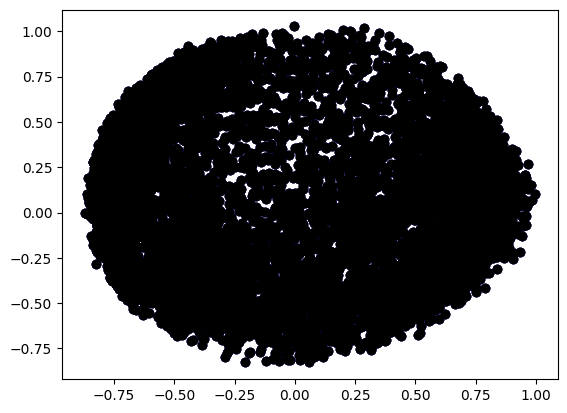

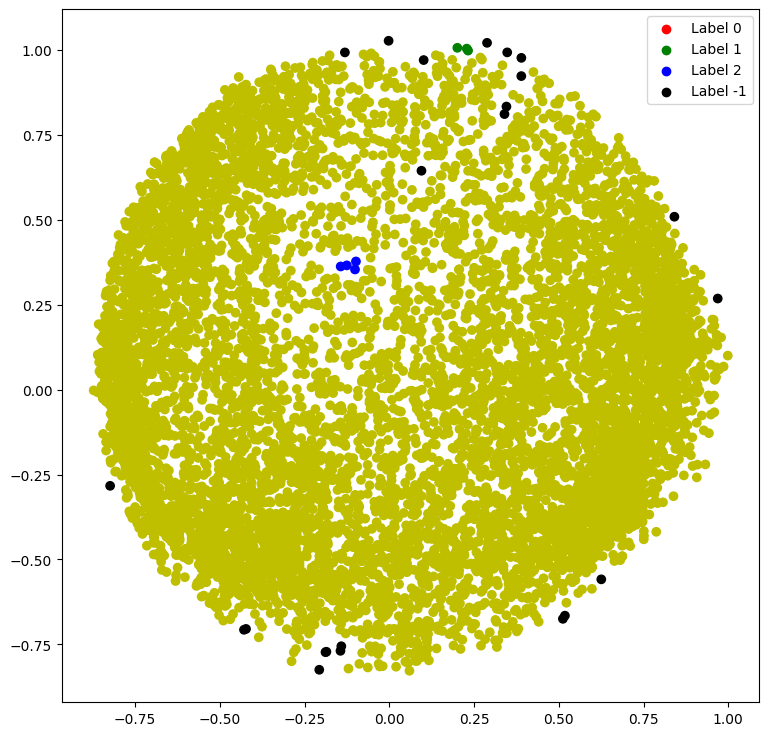

In [32]:
db_default = DBSCAN(eps=0.0375 , min_samples=3).fit(x_principal)
labels = db_default.labels_

colours = {}
colours[0] = 'y'
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'

cvec = [colours[label] for label in labels]
r= plt.scatter(x_principal['P1'],x_principal['P2'], color='r');
g= plt.scatter(x_principal['P1'],x_principal['P2'], color='g');
b= plt.scatter(x_principal['P1'],x_principal['P2'], color='b');
k= plt.scatter(x_principal['P1'],x_principal['P2'], color='k');

plt.figure(figsize=(9,9))
plt.scatter(x_principal['P1'],x_principal['P2'] , c=cvec)

plt.legend((r,g,b,k) , ('Label 0' , 'Label 1' , 'Label 2' , 'Label -1'))
plt.show()

TypeError: float() argument must be a string or a number, not 'PathCollection'

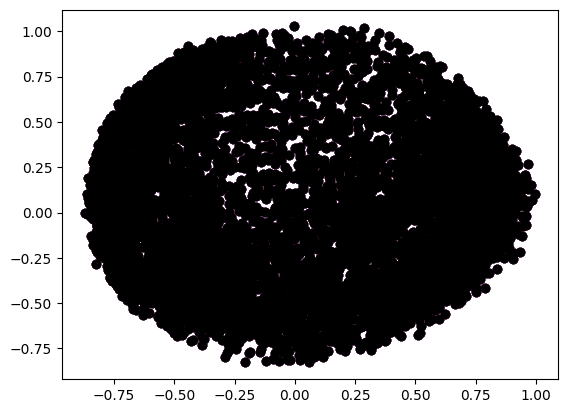

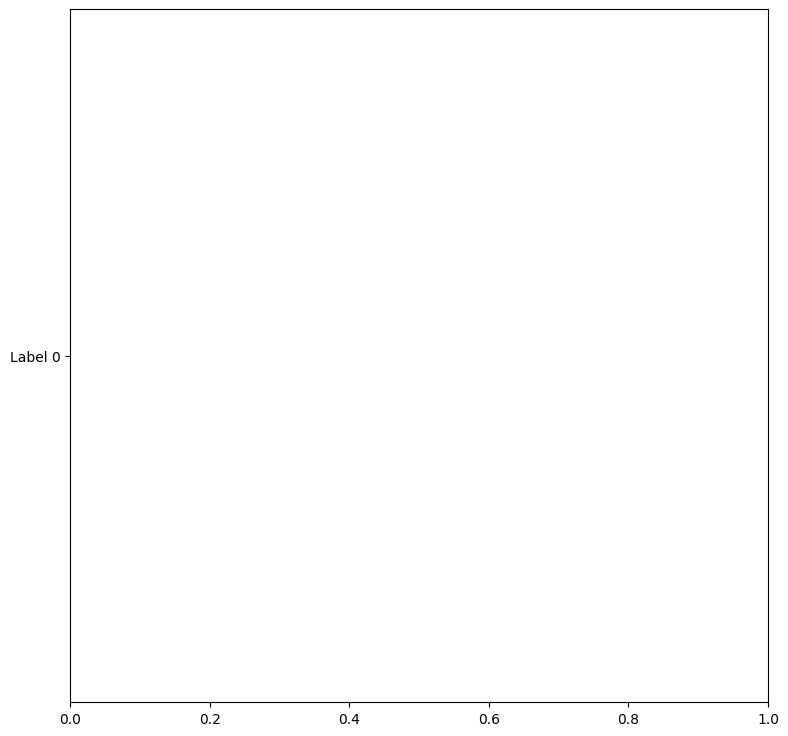

In [33]:
db = DBSCAN(eps=0.0375 , min_samples=50).fit(x_principal)
labels1 = db.labels_

colours1 = {}
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'

cvec = [colours1[label] for label in labels1]
colors1 = ['r' ,'g','b' ,'c','y','m','k']

r= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[0])
g= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[1])
b= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[2])
c= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[3])
y= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[4])
m= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[5])
k= plt.scatter(x_principal['P1'] , x_principal['P2'] , marker='o' , color=colours1[-1])

plt.figure(figsize=(9,9))
plt.scatter(x_principal['P1'], x_principal['P2'] ,c=cvec)
plt.legend((r,g,b,c,y,m,k) ,
            ('Label 0' ,'Label 1','Label 2','Label 3','Label 4','Label 5','Label -1'),
            scatterpoints=1 ,
            loc='upper left' ,
            ncol=3 ,
            fontsize=8)

plt.show()
